尖峰区域: [16.3, 17.0] 度
背景密度: 150.00 events/deg
尖峰密度: 1398.57 events/deg
建议保留比例 (Keep Ratio): 0.0644
原始事件数: 10070
处理后事件数: 9148
移除了 922 个异常事件


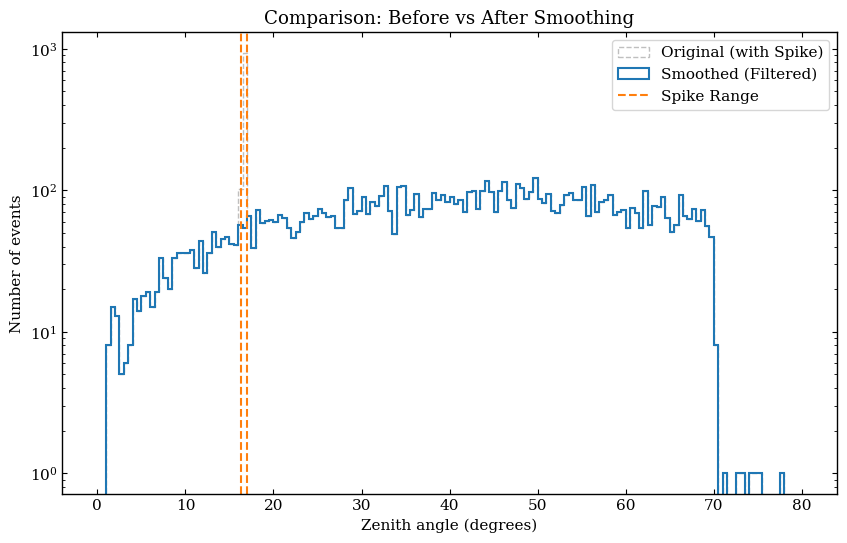

新文件已保存至: /data/home/zzh/data/Dataset_Filted/Monopole/1e12/filted_Monopole_combined_1e11_V04_dataset_fastcode_smooth.npz


In [36]:

import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. 加载数据
file_path = "/data/home/zzh/data/Dataset_Filted/Monopole/1e12/filted_Monopole_combined_1e11_V04_dataset_fastcode.npz"
mn_data = np.load(file_path, allow_pickle=True)
hitsE = mn_data['hitsE']; hitsM = mn_data['hitsM']
params = mn_data['params']
param_names = mn_data['param_names']

# 转为 DataFrame 方便操作
mn_df = pd.DataFrame(params, columns=param_names)

# 计算角度（用于筛选）
theta_deg = mn_df['rec_theta'].values * 180 / np.pi

# ==========================================
# 2. 定义尖峰范围和背景范围 (根据你的图目测)
# ==========================================
# 尖峰中心大约在 17 度，宽度看起来很窄
spike_low  = 16.3
spike_high = 17.

# 用来计算“正常水平”的邻域范围 (Sidebands)
# 选取尖峰左右两边比较平滑的区域
bg_range_mask = (
    ((theta_deg >= 16.) & (theta_deg < spike_low)) | 
    ((theta_deg > spike_high) & (theta_deg <= 17.5)) 
)

# ==========================================
# 3. 计算保留概率
# ==========================================

# 统计邻域内的平均密度 (events per degree)
bg_events_count = np.sum(bg_range_mask)
bg_width = (spike_low - 16.) + (17.5 - spike_high)
bg_density = bg_events_count / bg_width  # 单位：事件数/度

# 统计尖峰区域内的当前密度
spike_mask = (theta_deg >= spike_low) & (theta_deg <= spike_high)
spike_events_count = np.sum(spike_mask)
spike_width = spike_high - spike_low
current_spike_density = spike_events_count / spike_width 

# 计算保留比例 (Keep Ratio)
# 如果尖峰密度比背景大，就需要降采样；如果反而小了(不太可能)，就全保留(ratio=1)
if current_spike_density > bg_density:
    keep_ratio = bg_density / current_spike_density *0.6
else:
    keep_ratio = 1.0

print(f"尖峰区域: [{spike_low}, {spike_high}] 度")
print(f"背景密度: {bg_density:.2f} events/deg")
print(f"尖峰密度: {current_spike_density:.2f} events/deg")
print(f"建议保留比例 (Keep Ratio): {keep_ratio:.4f}")

# ==========================================
# 4. 执行“抹平”操作
# ==========================================

# 生成一个随机数数组，长度等于总数据量
random_probs = np.random.rand(len(mn_df))

# 构建最终的筛选 Mask
# 逻辑：
# 1. 如果不在尖峰区域 -> 也就是 (NOT spike_mask) -> 全部保留 (True)
# 2. 如果在尖峰区域 -> 只有当 random_probs < keep_ratio 时保留
final_mask = (~spike_mask) | (random_probs < keep_ratio)

# 应用筛选
mn_df_cleaned = mn_df[final_mask]
hitsE_cleaned = hitsE[final_mask]
hitsM_cleaned = hitsM[final_mask]

print(f"原始事件数: {len(mn_df)}")
print(f"处理后事件数: {len(mn_df_cleaned)}")
print(f"移除了 {len(mn_df) - len(mn_df_cleaned)} 个异常事件")

# ==========================================
# 5. 画图对比 (检查效果)
# ==========================================
plt.figure(figsize=(10, 6))

# 原始数据
plt.hist(theta_deg, range=[0, 80], bins=160, 
         histtype='step', color='gray', linestyle='--', label='Original (with Spike)', alpha=0.5)

# 处理后数据
cleaned_theta = mn_df_cleaned['rec_theta'].values * 180 / np.pi
plt.hist(cleaned_theta, range=[0, 80], bins=160, 
         histtype='step', color='tab:blue', linewidth=1.5, label='Smoothed (Filtered)')

plt.axvline(spike_low, color='tab:orange', linestyle='--', label='Spike Range')
plt.axvline(spike_high, color='tab:orange', linestyle='--')
plt.xlabel('Zenith angle (degrees)')
plt.ylabel('Number of events')
plt.yscale('log')
plt.title('Comparison: Before vs After Smoothing')
plt.legend()
plt.show()

# ==========================================
# 6. 保存新的 npz 文件
# ==========================================
# 假设你想保存回同样的格式
save_path = "/data/home/zzh/data/Dataset_Filted/Monopole/1e12/filted_Monopole_combined_1e11_V04_dataset_fastcode_smooth.npz"

np.savez(
    save_path, 
    hitsE = hitsE_cleaned,
    hitsM = hitsM_cleaned,
    params=mn_df_cleaned.values,  # 保存过滤后的 numpy 数组
    param_names=param_names       # 保持列名不变
)

print(f"新文件已保存至: {save_path}")



In [50]:

import numpy as np
import pandas as pd
import os
import argparse
from tqdm import tqdm




def npz_to_df_csv(npz_file):
    data = np.load(npz_file, allow_pickle=True)
    df = pd.DataFrame(data['params'], columns=data['param_names'])
    df.to_csv(npz_file.replace(".npz", ".csv"), index=False)
    print(df.head())

npz_file="/data/home/zzh/data/Dataset_Filted/Experiment/2024/2024_Rue_19_cut_1e11_V04_361days_dataset_fastcode.npz"
npz_to_df_csv(npz_file)


  label weight      R_ue     R_mean      Eage compactness  pincness  \
0    -1      1 -1.932304  17.912209  1.160559    0.282348     0.875   
1    -1      1 -2.038391  11.882792  1.187304    0.413719  0.905455   
2    -1      1 -1.985982  23.004936  0.905525    0.176511  0.893939   
3    -1      1 -2.068036  38.456532  1.194609    0.480069  0.915625   
4    -1      1 -2.012378  17.603069  1.120717    0.284453  0.915966   

        rho40      recE       rec_x  ... core_x core_y theta phi          dr  \
0   156.62131  2.667774  317.261078  ...   -1.0   -1.0  -1.0  -1   39.281818   
1  127.573761  2.524164  -467.59903  ...   -1.0   -1.0  -1.0  -1   130.41571   
2  254.966672  2.914607  546.974426  ...   -1.0   -1.0  -1.0  -1   11.192403   
3  125.368661  2.516816  376.427856  ...   -1.0   -1.0  -1.0  -1  166.498154   
4  193.507428  2.820235 -349.873383  ...   -1.0   -1.0  -1.0  -1   21.484959   

        NuW3      NuW2           mjd       tlong       tlat  
0  13.216811  2.858648  60309.

In [1]:
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
import joblib
import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
def give_sig_weights(monopole_df):
    file = uproot.open("/data/home/zzh/data/exposure_Gaisser.root")
    h1 = file["h1"]
    h2 = file["h2"]
    # 获取直方图的所有数据
    values = h1.values()        # bin内容（纵坐标）
    h2_values = h2.values()        # bin内容（纵坐标）
    edges = h1.axis().edges()   # bin边界（横坐标）
    h2_edges = h2.axis().edges()   # bin边界（横坐标）
    centers = h1.axis().centers()  # bin中心
    h2_centers = h2.axis().centers()  # bin中心

    values = np.array(h1.values())
    edges = np.array(h1.axis().edges())
    centers = np.array(h1.axis().centers())
    S=np.pi * 1000**2
    parker=1e-15 * 1e4 
    nums=[]
    for i, theta in enumerate(centers):
        cosine_theta = np.cos(np.deg2rad(theta))
        area = S * cosine_theta
        exposure = values[i] * area
        num_i = exposure * parker
        nums.append(num_i)

    weights=[num_i/25800/h2_values[i]/86400 for i, num_i in enumerate(nums)]
    theta_degrees = monopole_df["theta"] * 180 / np.pi
    monopole_weights = []
    for theta in theta_degrees:
        if theta > max(centers) or theta < 0:
            weight = weights[-1] if theta > max(centers) else 0
        else:
            bin_id = np.digitize(theta, edges) - 1
            weight = weights[bin_id]
        monopole_weights.append(weight)
  
    monopole_df["weight"] = np.asarray(monopole_weights) / (9148/10070)
    # print(f"======> Total expected monopole events after weighting: {monopole_df['weight'].sum()} ======")
    return monopole_df

def give_bkg_mc_weights_gaisser(pr_df: pd.DataFrame):
    rootfile = "/data/home/zzh/data/exposure_Gaisser.root"
    with uproot.open(rootfile) as f:
        hWeight = f["hWeight"]
        edges_E = hWeight.axes[0].edges()  # Energy bin edges
        edges_Zen = hWeight.axes[1].edges()  # Zenith bin edges
        weights_2d = hWeight.values()

    def add_weights(trueE, rec_zenith, weights_2d):
        trueE=np.log10(trueE/1e3)
        rec_zenith=180/np.pi*rec_zenith
        bin_idx_E = np.digitize(trueE, edges_E) - 1
        bin_idx_Zen = np.digitize(rec_zenith, edges_Zen) - 1
        if bin_idx_E >= weights_2d.shape[0]:
            bin_idx_E = weights_2d.shape[0] - 1
        if bin_idx_Zen >= weights_2d.shape[1]:
            bin_idx_Zen = weights_2d.shape[1] - 1
        return weights_2d[bin_idx_E, bin_idx_Zen]
    
    pr_df['gaisser_weight']=pr_df.apply(lambda row: add_weights(row['trueE'],row['rec_theta'],weights_2d),axis=1)
    pr_df['gaisser_weight']=pr_df['gaisser_weight']/86400
    pr_df['weight']=pr_df['gaisser_weight']
    # print(f"======> Total expected background MC events after weighting: {pr_df['gaisser_weight'].sum()} ======")
    return pr_df

def give_exp_weights(exp_df, Ndays):
    exp_df['weight'] = np.ones(len(exp_df)) / Ndays / 86400
    # print(f"======> Total expected exposure events after weighting: {exp_df['weight'].sum()} ======")
    return exp_df

# load data
##########################################################################################################################################
pr_file = "/data/home/zzh/data/Dataset_Filted/Simulation/1e11_V04/Proton_combined_filted_1e11_V04_dataset_fastcode.npz"
pr_data = np.load(pr_file, allow_pickle=True)
pr_df = pd.DataFrame(pr_data['params'], columns=pr_data['param_names'])
pr_df = give_bkg_mc_weights_gaisser(pr_df)
##########################################################################################################################################
file_path = "/data/home/zzh/data/Dataset_Filted/Monopole/1e11/filted_Monopole_combined_1e11_V04_dataset_fastcode_smooth.npz"
data = np.load(file_path, allow_pickle=True)
mn_df = pd.DataFrame(data['params'], columns=data['param_names'])
mn_df['NuW3'] = pd.to_numeric(mn_df['NuW3'], errors='coerce'); mn_df['rec_theta'] = pd.to_numeric(mn_df['rec_theta'], errors='coerce')
mn_df['rec_x'] = pd.to_numeric(mn_df['rec_x'], errors='coerce'); mn_df['rec_y'] = pd.to_numeric(mn_df['rec_y'], errors='coerce'); mn_df['rec_r'] = np.hypot(mn_df['rec_x'], mn_df['rec_y'])
mn_df = mn_df.dropna(subset=['NuW3', 'rec_theta']); mn_df = mn_df[mn_df['NuW3'] > 0]; mn_df = mn_df[mn_df['rec_theta'] > 0]
mn_df = give_sig_weights(mn_df)
mn_df['NuW3_log'] = np.log10(mn_df['NuW3'])
X = mn_df[['NuW3_log', 'rec_theta']].values
print(X.shape)
model = xgb.XGBRegressor(); model._estimator_type = "regressor"
model.load_model("./models/energy_correction_xgb_NuW3_8-12_higher.json")
y_pred = model.predict(X)
mn_df['recE'] = y_pred
##########################################################################################################################################
exp_file="/data/home/zzh/data/Dataset_Filted/Experiment/2024/2024_Rue_19_cut_1e11_V04_361days_dataset_fastcode.npz"
exp_data = np.load(exp_file, allow_pickle=True); exp_df = pd.DataFrame(exp_data['params'], columns=exp_data['param_names']); del exp_data
exp_df = give_exp_weights(exp_df, 361)
##########################################################################################################################################
print(f" Proton events: {pr_df.shape[0]}={pr_df['weight'].sum()},\n Monopole events: {mn_df.shape[0]}={mn_df['weight'].sum()}, \n Experiment events: {exp_df.shape[0]}={exp_df['weight'].sum()}")


(9148, 2)
 Proton events: 64308=1.6060293665648933,
 Monopole events: 9148=2.8093758082273337e-05, 
 Experiment events: 161654=0.005182812660305736


In [5]:
# mn_df[(mn_df['rec_r']>320) & (mn_df['rec_r']<420) & (mn_df['rec_theta']<np.deg2rad(35))]['weight'].sum()*86400*365
mn_df[(mn_df['recE']>2.8) & (mn_df['recE']<3.1)]['weight'].sum()/mn_df['weight'].sum()


np.float64(0.8246746278797874)

True energy range: 5.01e+05 - 4.69e+06 GeV


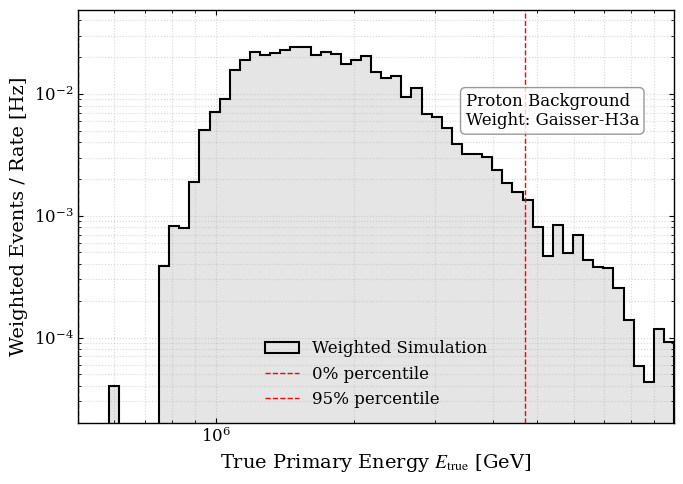

True energy range: 4.62e-01 - 3.10e+00 GeV


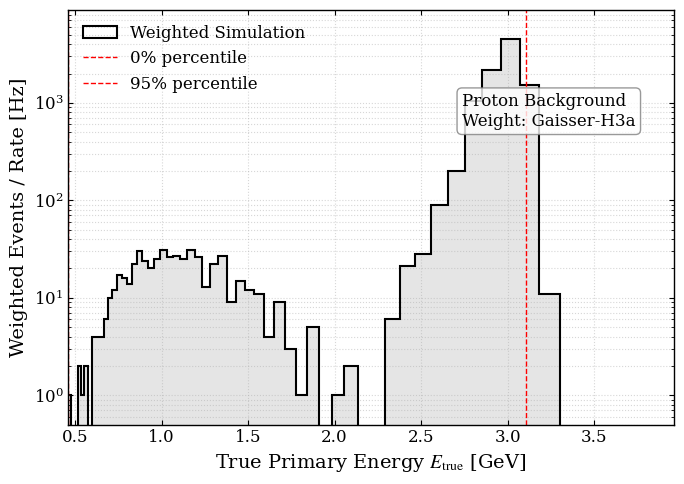

In [72]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- 1. 学术风格设置 ---
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "Liberation Serif", "serif"],
    "font.size": 12,
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "mathtext.fontset": "stix"
})

def plot_background_spectrum(df, recE=False):
    # --- 2. 数据准备 ---
    # 提取真能量和权重
    true_e = df['trueE'].values if not recE else df['recE'].values
    weights = df['gaisser_weight'].values if 'gaisser_weight' in df.columns else df['weight'].values

    low, high = (0,95)
    low_perc, high_perc = np.percentile(true_e, (low, high) )
    print(f"True energy range: {low_perc:.2e} - {high_perc:.2e} GeV")
    # --- 关键步骤：设置对数 Binning ---
    # 宇宙线能谱通常跨越多个数量级，线性 Bin (bins=100) 会导致低能堆积，高能看不见
    # 我们根据数据的最大最小值生成对数均匀的 Bin
    min_e = np.min(true_e[true_e > 0]) # 防止 log(0)
    max_e = np.max(true_e)
    # 生成 60 个对数均匀的 bin
    log_bins = np.logspace(np.log10(min_e), np.log10(max_e), 60)
    
    # --- 3. 绘图 ---
    fig, ax = plt.subplots(figsize=(7, 5))
    
    # 绘制加权直方图
    # 使用 'step' 风格，颜色使用标准的深灰色或黑色，符合学术习惯
    counts, edges, _ = ax.hist(true_e, bins=log_bins, weights=weights,
                               histtype='step', color='black', lw=1.5,
                               label='Weighted Simulation')
    
    # 填充颜色 (可选，增加美观度)
    ax.hist(true_e, bins=log_bins, weights=weights,
            histtype='stepfilled', color='gray', alpha=0.2)
    ax.axvline(low_perc, color='red', ls='--', lw=1, label=f'{low}% percentile')
    ax.axvline(high_perc, color='red', ls='--', lw=1, label=f'{high}% percentile')
    # --- 4. 坐标轴设置 ---
    ax.set_xscale('log') if not recE else ax.set_xscale('linear')
    ax.set_yscale('log')
    
    # 标签 (假设单位是 GeV，如果不是请修改)
    ax.set_xlabel(r"True Primary Energy $E_{\mathrm{true}}$ [GeV]", fontsize=14)
    ax.set_ylabel("Weighted Events / Rate [Hz]", fontsize=14)
    
    # 范围微调
    ax.set_xlim(min_e, max_e)
    # y轴下限设为非零的最小值，防止 log 轴显示问题
    if np.max(counts) > 0:
        ax.set_ylim(bottom=np.min(counts[counts > 0]) * 0.5, top=np.max(counts) * 2)

    # 图例与网格
    ax.legend(frameon=False, fontsize=12)
    ax.grid(True, which="both", ls=":", alpha=0.5)
    
    # 添加说明文本 (可选)
    ax.text(0.65, 0.8, "Proton Background\nWeight: Gaisser-H3a", 
            transform=ax.transAxes, va='top', fontsize=12,
            bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.8))

    plt.tight_layout()
    # plt.savefig("/data/home/zzh/Filt_Event/Note_Writing/figures/MC_Proton_Spectrum_1e10.pdf", bbox_inches='tight')
    plt.show()

# 执行绘图
plot_background_spectrum(pr_df[(pr_df['recE']>2.74) & (pr_df['recE']<3.15)])
plot_background_spectrum(mn_df, recE=True)


In [ ]:
query="R_ue < -2.5 & recE > 2.75 & recE < 3.25"
exp_df_SR = exp_df.query(query)
print(f"Experiment events in SR: {exp_df_SR.shape[0]}={exp_df_SR['weight'].sum()*86400*365}")
mn_df_SR = mn_df.query(query)
print(f"Monopole events in SR: {mn_df_SR.shape[0]}={mn_df_SR['weight'].sum()*86400*365}")


Experiment events in SR: 308=311.41274238227146
Monopole events in SR: 7288=707.8990747647588


: 

In [ ]:

Rue_high = -2.1
Rue_tmp_high=-2.5

recE_low=2.75
recE_high=3.25
pr_df_SR = pr_df[(pr_df['R_ue'] < Rue_tmp_high) & (pr_df['recE'] > recE_low) & (pr_df['recE'] < recE_high)]
mn_df_SR = mn_df[(mn_df['R_ue'] < Rue_high) & (mn_df['recE'] > recE_low) & (mn_df['recE'] < recE_high)]
print(f"Proton events in SR: {pr_df_SR.shape[0]}={pr_df_SR['weight'].sum()*86400*365},\n Monopole events in SR: {mn_df_SR.shape[0]}={mn_df_SR['weight'].sum()*86400*365}")


Proton events in SR: 4=3785.792235640216,
 Monopole events in SR: 8312=801.6318200694922


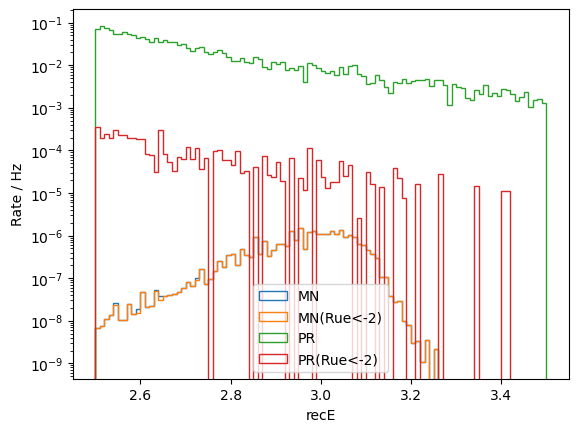

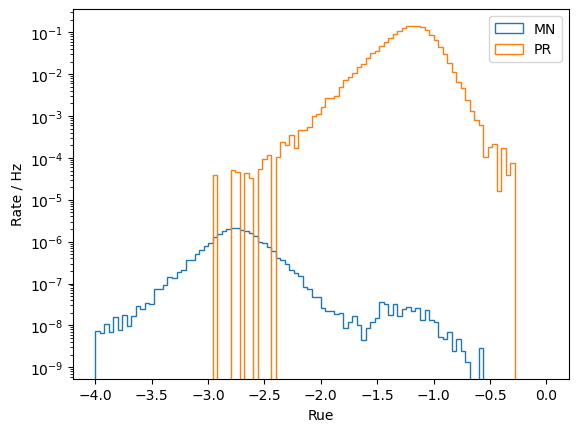

In [ ]:
# recE
recE_range=(2.5,3.5)
plt.hist(mn_df['recE'], bins=100, weights=mn_df['weight'], range=recE_range, histtype='step', label='MN', )
plt.hist(mn_df[mn_df['R_ue']<-2]['recE'], bins=100, weights=mn_df[mn_df['R_ue']<-2]['weight'], range=recE_range, histtype='step', label='MN(Rue<-2)', )
plt.hist(pr_df['recE'], bins=100, weights=pr_df['weight'], range=recE_range, histtype='step', label='PR', )
plt.hist(pr_df[pr_df['R_ue']<-2]['recE'], bins=100, weights=pr_df[pr_df['R_ue']<-2]['weight'], range=recE_range, histtype='step', label='PR(Rue<-2)', )
plt.legend()
plt.yscale('log')
plt.xlabel('recE')
plt.ylabel('Rate / Hz')
plt.show()

# Rue
Rue_range=(-4,0)
plt.hist(mn_df['R_ue'], bins=100, weights=mn_df['weight'], range=Rue_range, histtype='step', label='MN', )
plt.hist(pr_df['R_ue'], bins=100, weights=pr_df['weight'], range=Rue_range, histtype='step', label='PR', )
plt.legend()
plt.yscale('log')
plt.xlabel('Rue')
plt.ylabel('Rate / Hz')
plt.show()


In [27]:
pr_df[pr_df['R_ue']<-1.9]['weight'].sum()/pr_df['weight'].sum()


np.float64(0.006639515248111071)

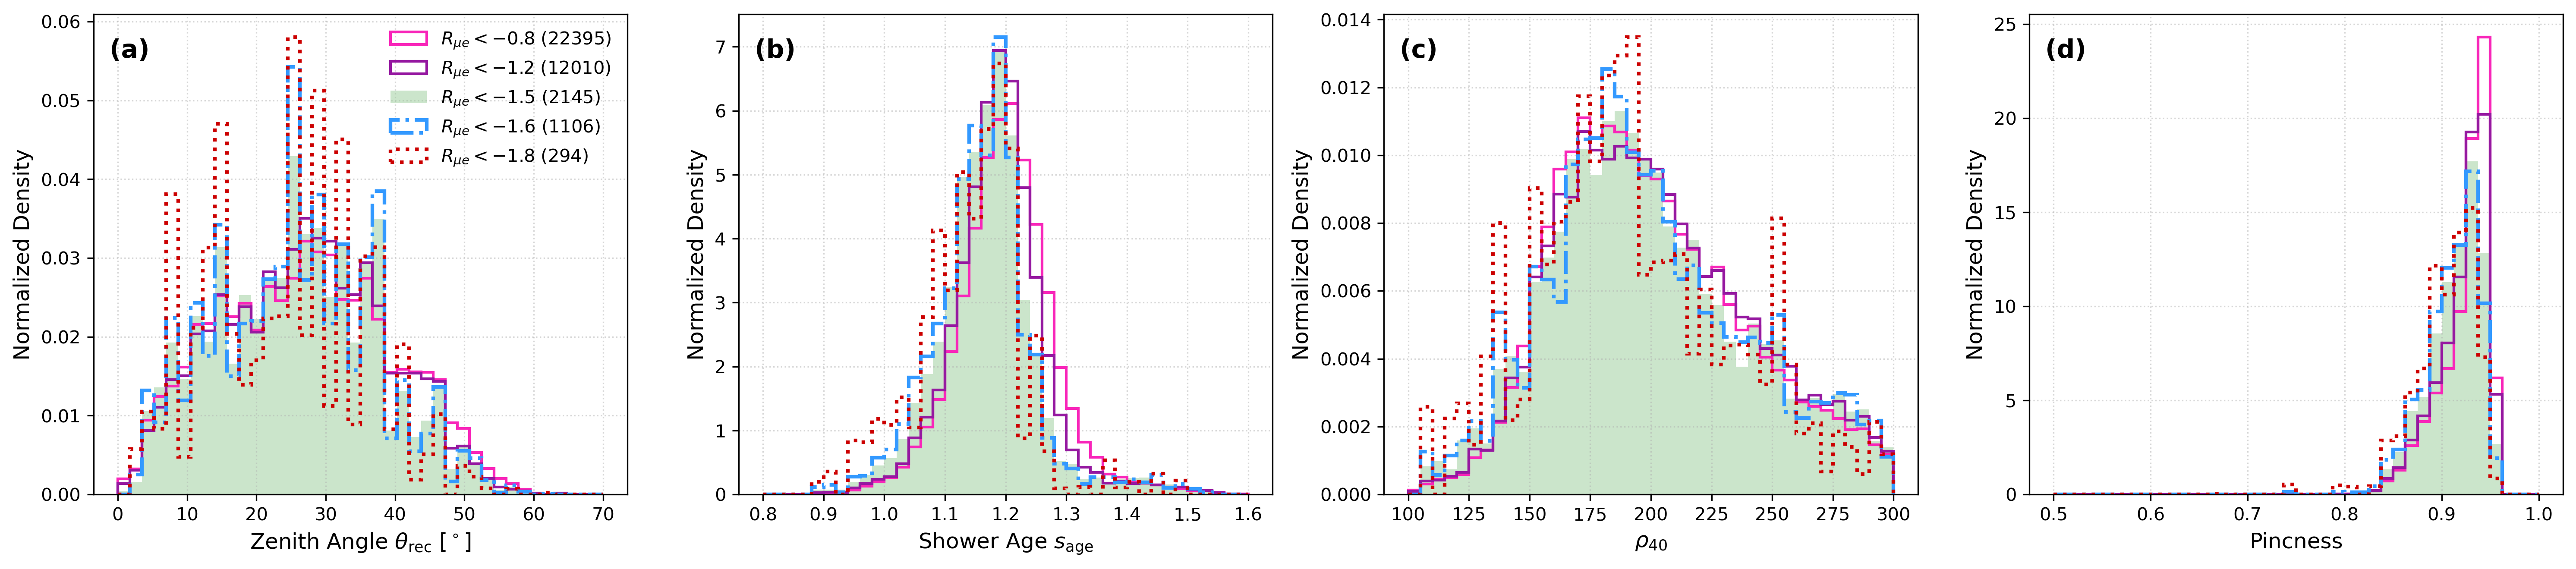

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import string

def plot_rue_trend(df_pr):
    # --- 1. 样式设置 ---
  

    # --- 2. 物理量定义 (只保留 theta 和 Age) ---
    param_configs = {
        'rec_theta': {'range': (0, 70),    'label': r'Zenith Angle $\theta_{\mathrm{rec}}$ [$^\circ$]'},
        'Eage':      {'range': (0.8, 1.6), 'label': r'Shower Age $s_{\mathrm{age}}$'},
        'rho40':     {'range': (100, 300),  'label': r'$\rho_{40}$'},
        'pincness':  {'range': (0.5, 1.0), 'label': 'Pincness'},
    }

    # --- 3. 数据预处理 ---
    df = df_pr.copy()
    df['recE'] = pd.to_numeric(df['recE'], errors='coerce')
    # 锁定能量窗口
    df = df[(df['recE'] > 2.75) & (df['recE'] < 3.2)]

    # --- 4. 定义切片 (Trend Slices) ---
    # 颜色逐渐加深，代表 Cut 越来越严
    slices = [
        {'cut_val': -0.8,  'color': "#f825b9", 'h_type':'step', 'alpha': 1, 'ls': '-',  'lw': 1.5, 'label': r'$R_{\mu e} < -0.8$'},
        {'cut_val': -1.2,  'color': "#9518a0", 'h_type':'step', 'alpha': 1, 'ls': '-',  'lw': 1.5, 'label': r'$R_{\mu e} < -1.2$'},
        {'cut_val': -1.5,  'color': '#99cc99', 'h_type':'stepfilled','alpha': 0.5,  'ls': '--', 'lw': 1.5, 'label': r'$R_{\mu e} < -1.5$'},
        {'cut_val': -1.6, 'color': '#3399ff',  'h_type':'step','alpha': 1, 'ls': '-.', 'lw': 2, 'label': r'$R_{\mu e} < -1.6$'},
        {'cut_val': -1.8,  'color': '#cc0000',  'h_type':'step','alpha': 1, 'ls': ':',  'lw': 2, 'label': r'$R_{\mu e} < -1.8$'},
    ]

    # --- 5. 绘图循环 ---
    n_params = len(param_configs)
    fig, axes = plt.subplots(1, n_params, figsize=(5*n_params, 4.5), dpi=300)
    
    for i, (p_name, p_cfg) in enumerate(param_configs.items()):
        ax = axes[i]
        
        for s in slices:
            # 应用 Cut
            mask = df['R_ue'] < s['cut_val']
            if not np.any(mask): continue
            
            vals = df.loc[mask, p_name].values
            weights = df.loc[mask, 'gaisser_weight'].values
            
            # 角度转换
            if p_name == 'rec_theta': vals = vals * (180/np.pi)

            # 绘图：关键是 density=True
            ax.hist(vals, bins=40, range=p_cfg['range'], weights=weights,
                    density=True, histtype=s['h_type'], alpha=s['alpha'],
                    color=s['color'], linestyle=s['ls'], linewidth=s['lw'],
                    label=s['label']+f" ({mask.sum()})")
        
        # 标签与美化
        ax.text(0.03, 0.95, f'({string.ascii_lowercase[i]})', 
                transform=ax.transAxes, fontsize=14, fontweight='bold', va='top')
        ax.set_xlabel(p_cfg['label'], fontsize=12)
        ax.set_ylabel("Normalized Density", fontsize=12)
        # ax.set_title(f'({string.ascii_lowercase[i]})', loc='left', fontweight='bold')
        
        # 只在第一张图显示 Legend
        if i == 0: 
            ax.legend(frameon=False, fontsize=10, loc='best')
        
        ax.grid(True, ls=':', alpha=0.5)

    plt.tight_layout()
    # plt.savefig("/data/home/zzh/Filt_Event/Note_Writing/figures/Background_Shape_Stability_Trend.pdf", bbox_inches='tight')
    plt.show()

# 执行
plot_rue_trend(pr_df)


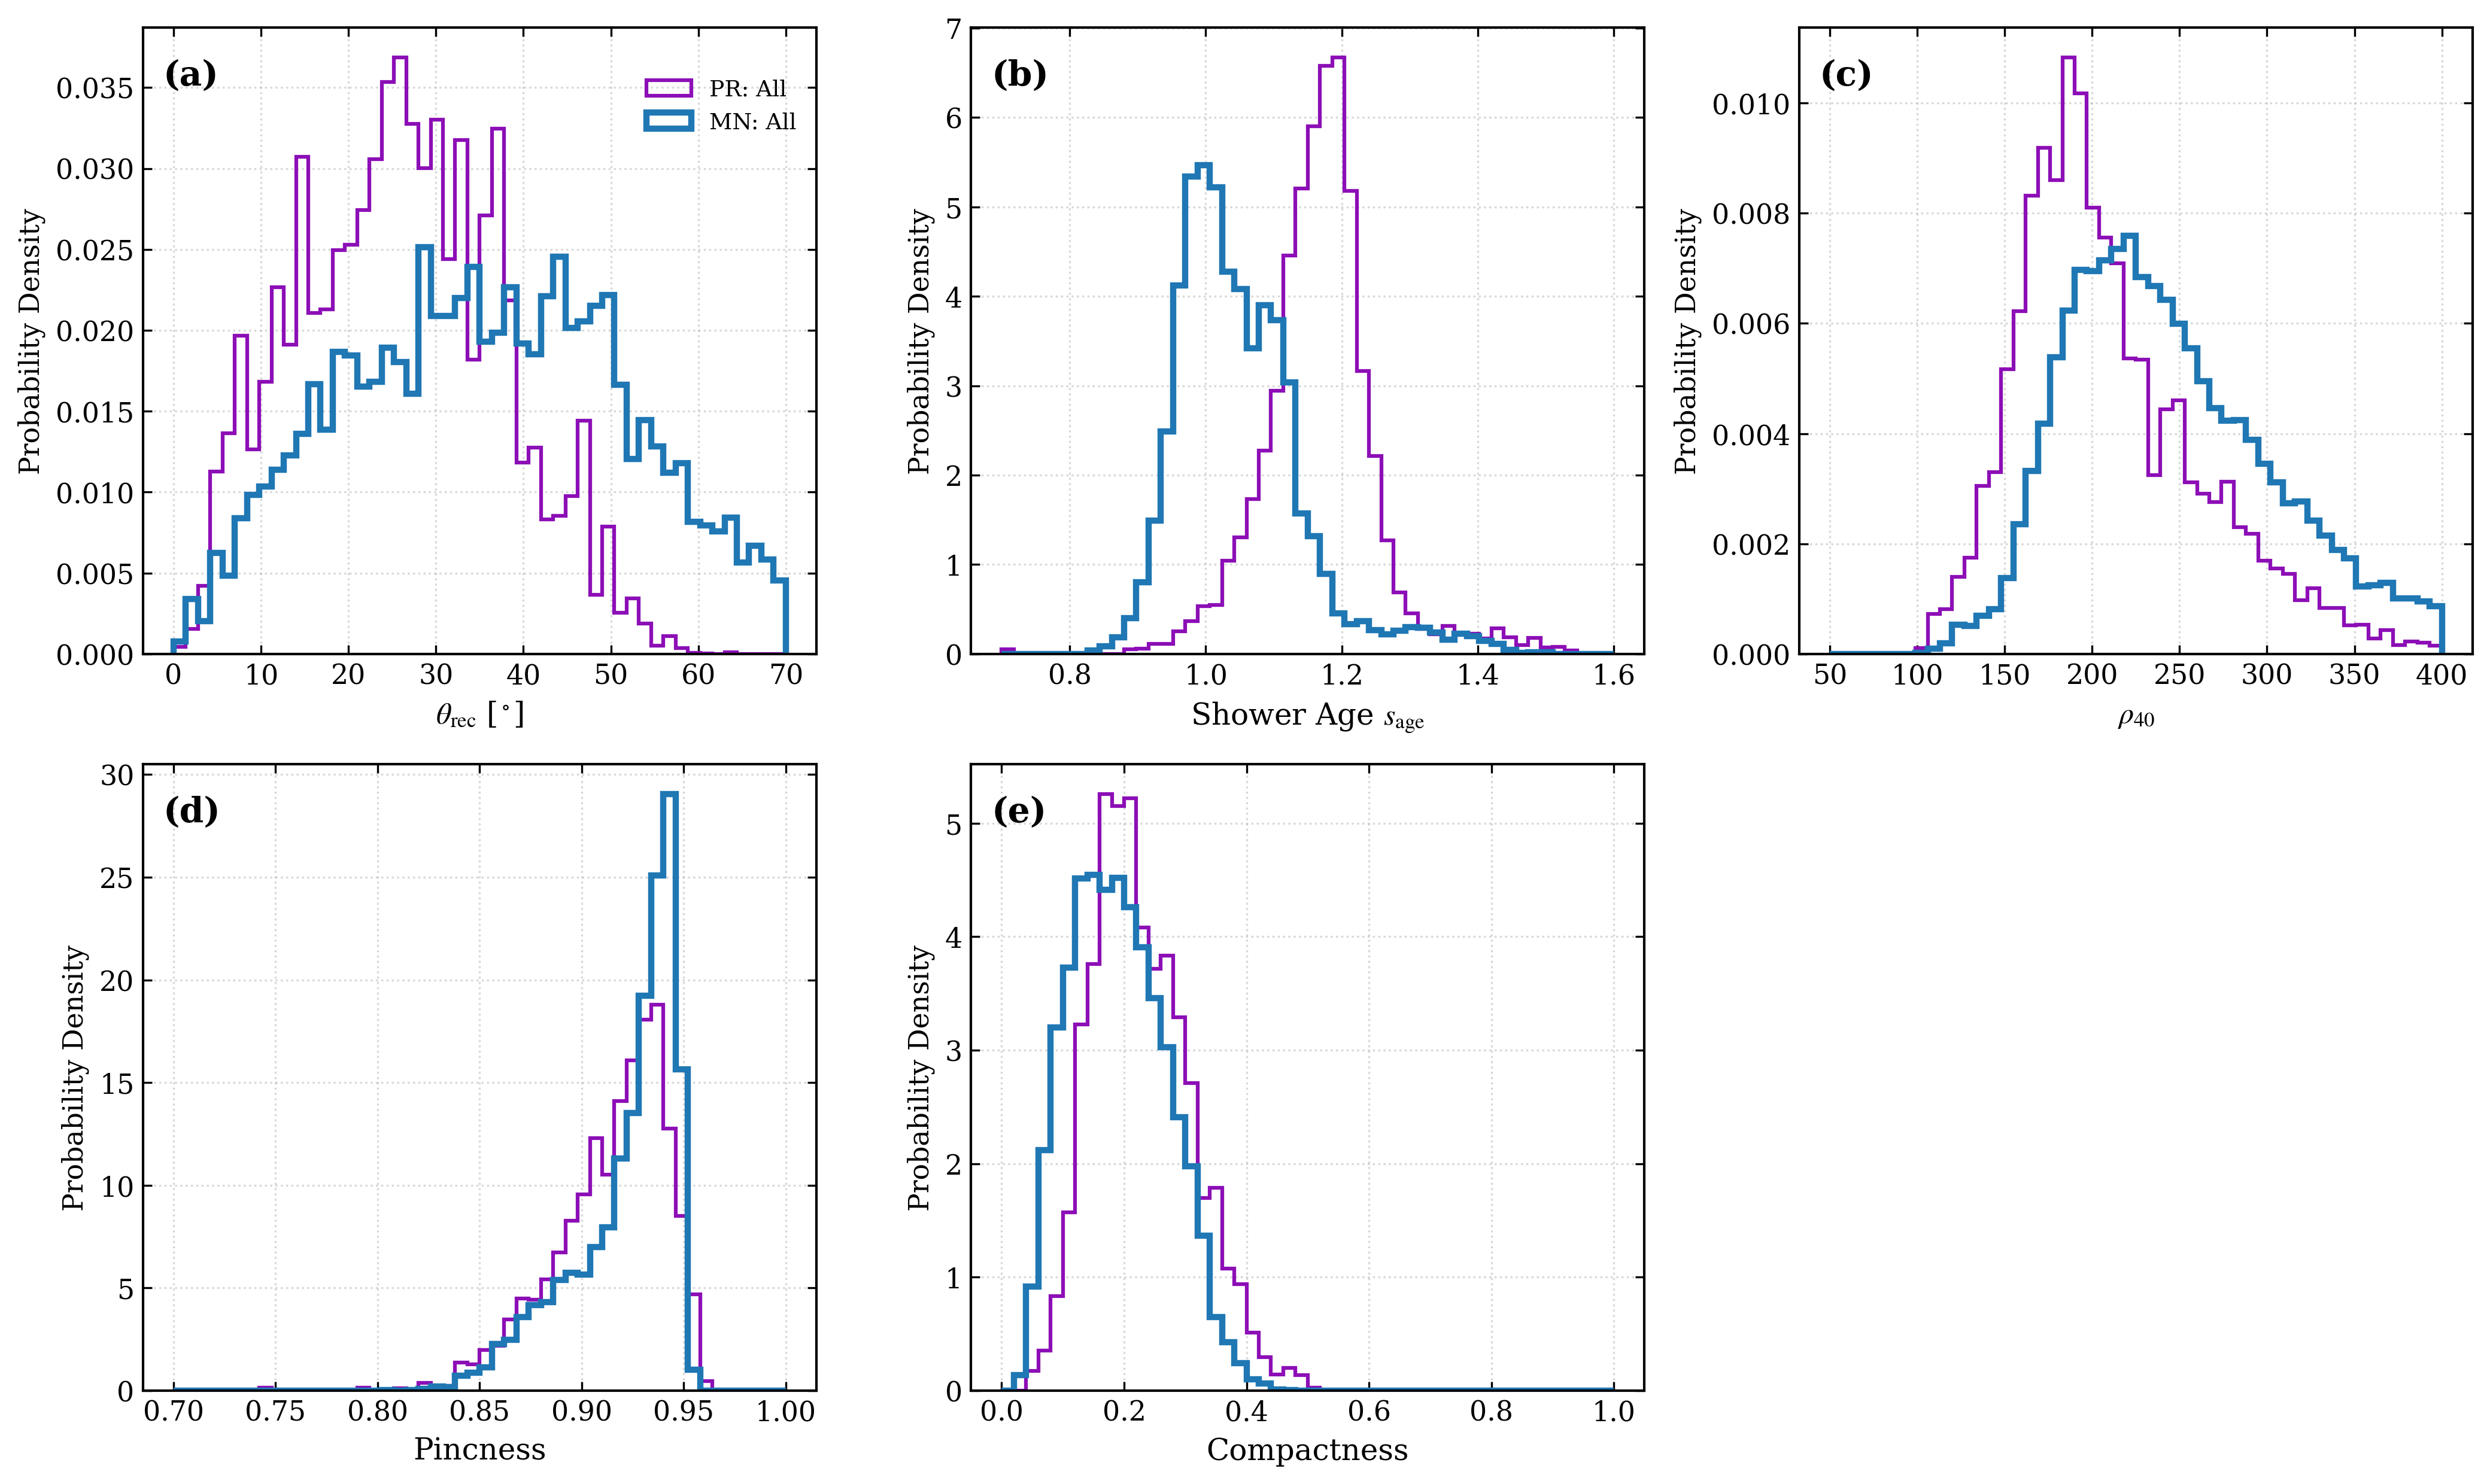

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import string
def generate_bin_labels(bins):
    """根据 bins 列表自动生成数学表达式标签"""
    labels = []
    for i in range(len(bins) - 1):
        low, high = bins[i], bins[i+1]
        if low == -np.inf and high == np.inf:
            labels.append("All")
        elif low == -np.inf:
            labels.append(f'$R_{{ue}} < {high}$')
        elif high == np.inf:
            labels.append(f'$R_{{ue}} > {low}$')
        else:
            labels.append(f'${low} < R_{{ue}} < {high}$')
    return labels
def plot_rue_slices(df_pr, df_exp=None, df_mn=None):
    # 1. 设置正式发表的学术风格
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "DejaVu Serif", "serif"],
        "mathtext.fontset": "stix",
        "font.size": 11,
        "axes.linewidth": 1.0,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True
    })

    # 物理参数配置
    param_configs = {
        'rec_theta': {'range': (0, 70),    'label': r'$\theta_{\mathrm{rec}}$ [$^\circ$]'},
        'Eage':      {'range': (0.7, 1.6), 'label': r'Shower Age $s_{\mathrm{age}}$'},
        'rho40':     {'range': (50, 400),  'label': r'$\rho_{40}$'},
        'pincness':  {'range': (0.7, 1), 'label': 'Pincness'},
        'compactness':{'range': (0.0, 1.0), 'label': 'Compactness'},
    }

    # 2. 预处理数据 (包含 recE 筛选)
    def preprocess_df(df):
        if df is None: return None
        # 确保数据为数值型
        df['recE'] = pd.to_numeric(df['recE'], errors='coerce')
        mask_e = (df['recE'] > 2.5) & (df['recE'] < 3.5)
        return df[mask_e].copy()

    # 核心配置 
    raw_configs = {
        'PR':  {'df': preprocess_df(df_pr), 'bins': [-np.inf,np.inf], 
                'w': 'gaisser_weight', 'style': {'histtype': 'step', 'lw': 1.5}},
        # 'Exp': {'df': preprocess_df(df_exp), 'bins': [-np.inf, -3.0], 
        #         'w': 'weight', 'style': {'histtype': 'stepfilled', 'alpha': 0.15}},
        'MN':  {'df': preprocess_df(df_mn), 'bins': [-np.inf, np.inf], 
                'w': 'weight', 'style': {'histtype': 'step', 'lw': 2.5}}
    }

    data_sources = {k: v for k, v in raw_configs.items() if v['df'] is not None}
    for k in data_sources:
        data_sources[k]['labels'] = generate_bin_labels(data_sources[k]['bins'])

    # 3. 布局
    n_params = len(param_configs)
    n_cols = 3
    n_rows = (n_params + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4.2 * n_rows), dpi=300)
    axes_flat = axes.flatten()

    # 4. 绘图循环
    for i, (p_name, p_cfg) in enumerate(param_configs.items()):
        ax = axes_flat[i]
        
        for src_name, s in data_sources.items():
            df_slice = s['df']
            # 使用 pd.cut 确保筛选逻辑正确
            categories = pd.cut(df_slice['R_ue'], bins=s['bins'], labels=False)
            
            for j, bin_label in enumerate(s['labels']):
                mask = (categories == j)
                if not np.any(mask): continue
                
                # 配色逻辑
                if src_name == 'MN': 
                    c = '#1f77b4'  # 信号蓝
                elif src_name == 'Exp': 
                    c = '#d62728'  # 实验红（根据您代码中Exp的颜色）
                else: 
                    pr_colors = ["#8C0EB6", '#FF7F0E'] # 背景颜色
                    c = pr_colors[j % len(pr_colors)]

                # 计算绘图值
                plot_vals = pd.to_numeric(df_slice.loc[mask, p_name], errors='coerce').values
                if p_name == 'rec_theta' and np.nanmax(plot_vals) < 7:
                    plot_vals = plot_vals * (180/np.pi)

                ax.hist(plot_vals, bins=50, density=True, range=p_cfg['range'],
                        weights=df_slice.loc[mask, s['w']].values, color=c,
                        label=f"{src_name}: {bin_label}", **s['style'])
        
        # --- 核心修改：添加 (a), (b), (c)... 标签 ---
        # transform=ax.transAxes 表示使用子图相对坐标 (0,0)左下, (1,1)右上
        ax.text(0.03, 0.95, f'({string.ascii_lowercase[i]})', 
                transform=ax.transAxes, fontsize=14, fontweight='bold', va='top')

        if i == 0: 
            ax.legend(fontsize=9, frameon=False, loc='upper right', bbox_to_anchor=(1.0, 0.95))
        
        # 子图美化
        ax.set_xlabel(p_cfg['label'], fontsize=12)
        ax.set_ylabel("Probability Density", fontsize=11)
        ax.grid(True, ls=':', alpha=0.5)

    # 5. 隐藏多余子图
    for j in range(i + 1, len(axes_flat)):
        fig.delaxes(axes_flat[j])

    plt.tight_layout()
    # plt.savefig("/data/home/zzh/Filt_Event/Note_Writing/figures/Variables_For_Classification_compare.pdf", bbox_inches='tight', dpi=300)
    plt.show()

# 执行绘图
plot_rue_slices(pr_df_SR, df_mn=mn_df_SR)
